# Experiment 4 — Pass@N before and after GRPO

Each condition contains 256 independently sampled responses for every question in the full 1,319-question GSM8K test set. 

Qwen2.5-0.5B and OLMo-2-0425-1B use the same three-shot R1 prompt, strict answer-and-format reward, top-p 1, 128-token output limit, and per-question seeds. 

Sampling temperature is varied over 0.5, 1.0, and 1.5. Both trained conditions use all-linear LoRA with rank 8 and alpha 16.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import PercentFormatter

ROOT = Path.cwd() if (Path.cwd() / "results").is_dir() else Path.cwd().parent
RESULTS = ROOT / "results" / "04_pass_at_n"
FIGURES = ROOT / "results" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

conditions = {
    "base": ("Qwen2.5-0.5B", "Base"),
    "grpo": ("Qwen2.5-0.5B", "GRPO"),
    "olmo_base": ("OLMo-2-0425-1B", "Base"),
    "olmo_grpo": ("OLMo-2-0425-1B", "GRPO"),
}
suffixes = {0.5: "_t0p5", 1.0: "", 1.5: "_t1p5"}
temperature_data = {
    (name, temperature): json.loads((RESULTS / f"{name}{suffix}.json").read_text())
    for name in conditions for temperature, suffix in suffixes.items()
}
data = {name: temperature_data[name, 1.0] for name in conditions}

assert all(x["n_examples"] == 1319 and x["config"]["n_samples"] == 256 for x in temperature_data.values())
assert all(len(x["records"]) == 1319 and len(x["pass_at_n"]) == 256 for x in temperature_data.values())
assert all(x["config"]["temperature"] == temperature for (_, temperature), x in temperature_data.items())
questions = [row["question"] for row in data["base"]["records"]]
assert all([row["question"] for row in x["records"]] == questions for x in temperature_data.values())
[(name, temperature, x["n_examples"]) for (name, temperature), x in temperature_data.items()]

[('base', 0.5, 1319),
 ('base', 1.0, 1319),
 ('base', 1.5, 1319),
 ('grpo', 0.5, 1319),
 ('grpo', 1.0, 1319),
 ('grpo', 1.5, 1319),
 ('olmo_base', 0.5, 1319),
 ('olmo_base', 1.0, 1319),
 ('olmo_base', 1.5, 1319),
 ('olmo_grpo', 0.5, 1319),
 ('olmo_grpo', 1.0, 1319),
 ('olmo_grpo', 1.5, 1319)]

## Estimator and protocol

For question $i$, let $c_i$ be the number of correct-and-formatted responses among $n=256$ samples. The standard order-invariant estimator is

$$\widehat{\mathrm{pass@N}}_i = 1 - \frac{\binom{256-c_i}{N}}{\binom{256}{N}}.$$

The reported curve averages this quantity over questions. It estimates whether **at least one** of N samples is correct, so it assumes an oracle/verifier and is not majority-vote accuracy. Conditions share questions and per-question seeds. Pointwise 95% intervals use normal intervals over questions; difference intervals use paired question-level differences. The first table retains the original T=1 base-versus-GRPO comparison, while subsequent outputs cover all temperatures.

In [2]:
def question_curve(correct, total=256):
    miss = np.ones(total)
    for k in range(1, total + 1):
        miss[k - 1] = 0 if total - correct < k else (miss[k - 2] if k > 1 else 1) * (total - correct - k + 1) / (total - k + 1)
    return 1 - miss

per_question_temperature = {
    key: np.stack([question_curve(row["n_correct"]) for row in payload["records"]])
    for key, payload in temperature_data.items()
}
per_question = {name: per_question_temperature[name, 1.0] for name in conditions}
N = np.arange(1, 257)
curves = {name: values.mean(0) for name, values in per_question.items()}
pairs = {"Qwen2.5-0.5B": ("base", "grpo"), "OLMo-2-0425-1B": ("olmo_base", "olmo_grpo")}
deltas = {model: per_question[trained] - per_question[base] for model, (base, trained) in pairs.items()}

selected = np.array([1, 2, 4, 8, 16, 25, 32, 64, 128, 256])
rows = []
for model, (base, trained) in pairs.items():
    delta = deltas[model]
    mean, se = delta.mean(0), delta.std(0, ddof=1) / np.sqrt(len(delta))
    for k in selected:
        rows.append({
            "Model": model, "N": k,
            "Base": curves[base][k - 1], "GRPO": curves[trained][k - 1],
            "Difference": mean[k - 1],
            "95% CI low": mean[k - 1] - 1.96 * se[k - 1],
            "95% CI high": mean[k - 1] + 1.96 * se[k - 1],
        })
summary = pd.DataFrame(rows).set_index(["Model", "N"])
summary.style.format("{:.2%}")

In [3]:
budget = pd.DataFrame([
    {
        "Model": conditions[name][0], "Condition": conditions[name][1], "Temperature": temperature,
        "Pass@1": payload["pass_at_n"][0], "Pass@25": payload["pass_at_n"][24],
        "Pass@256": payload["pass_at_n"][255], "Format rate": payload["format_rate"],
        "Runtime (min)": payload["elapsed_seconds"] / 60,
    }
    for (name, temperature), payload in temperature_data.items()
]).set_index(["Model", "Condition", "Temperature"]).sort_index()
budget.style.format({"Pass@1": "{:.2%}", "Pass@25": "{:.2%}", "Pass@256": "{:.2%}", "Format rate": "{:.2%}", "Runtime (min)": "{:.1f}"})

In [4]:
effects = []
for name, (model, condition) in conditions.items():
    reference = per_question_temperature[name, 1.0]
    for temperature in (0.5, 1.5):
        delta = per_question_temperature[name, temperature] - reference
        for k in (1, 25, 256):
            mean = delta[:, k - 1].mean()
            se = delta[:, k - 1].std(ddof=1) / np.sqrt(len(delta))
            effects.append({
                "Model": model, "Condition": condition, "Temperature": temperature, "N": k,
                "Difference vs T=1": mean,
                "95% CI low": mean - 1.96 * se,
                "95% CI high": mean + 1.96 * se,
            })
temperature_effects = pd.DataFrame(effects).set_index(["Model", "Condition", "Temperature", "N"])
temperature_effects.style.format("{:.2%}")

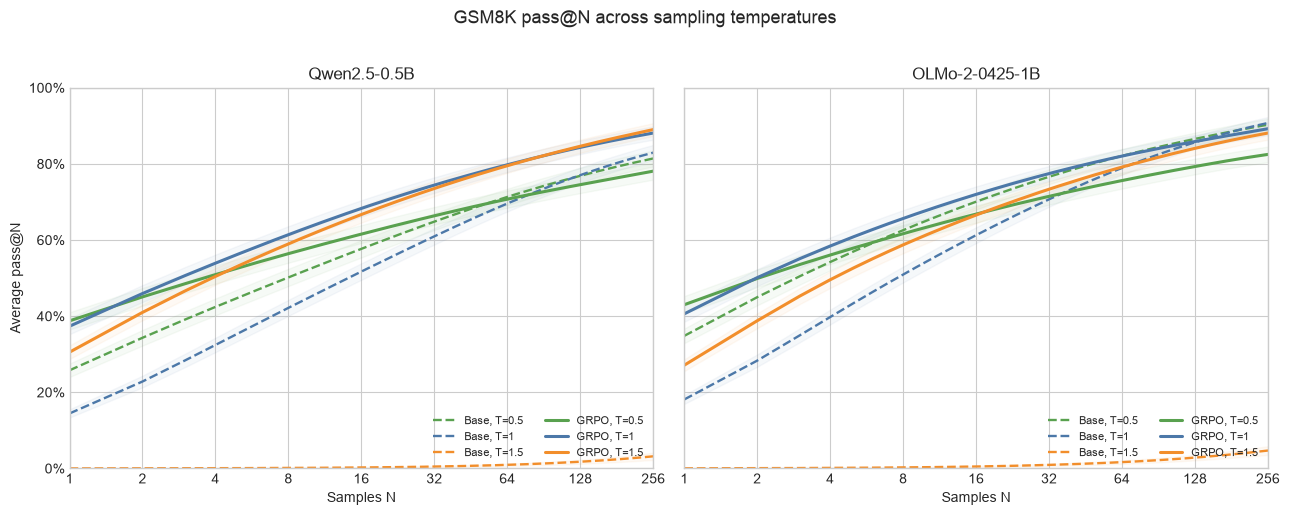

In [5]:
plt.style.use("seaborn-v0_8-whitegrid")
temperature_colors = {0.5: "#59A14F", 1.0: "#4C78A8", 1.5: "#F28E2B"}
condition_styles = {"Base": "--", "GRPO": "-"}
ticks = [1, 2, 4, 8, 16, 32, 64, 128, 256]
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)

for axis, (model, (base, trained)) in zip(axes, pairs.items(), strict=True):
    for name, condition in ((base, "Base"), (trained, "GRPO")):
        for temperature in suffixes:
            values = per_question_temperature[name, temperature]
            mean = values.mean(0)
            se = values.std(0, ddof=1) / np.sqrt(len(values))
            color = temperature_colors[temperature]
            axis.plot(N, mean, color=color, linestyle=condition_styles[condition],
                      linewidth=2.2 if condition == "GRPO" else 1.7,
                      label=f"{condition}, T={temperature:g}")
            axis.fill_between(N, mean - 1.96 * se, mean + 1.96 * se, color=color, alpha=.05)
    axis.set(title=model, xlabel="Samples N", xscale="log", xlim=(1, 256), ylim=(0, 1))
    axis.set_xticks(ticks, labels=ticks)
    axis.yaxis.set_major_formatter(PercentFormatter(1))
    axis.legend(loc="lower right", fontsize=8, ncol=2)
axes[0].set_ylabel("Average pass@N")

fig.suptitle("GSM8K pass@N across sampling temperatures", y=1.02, fontsize=13)
fig.tight_layout()
fig.savefig(FIGURES / "04_pass_at_n.png", dpi=180, bbox_inches="tight")
plt.show()

## Main observations

- **At T=1, GRPO strongly improves ordinary sampling.** Pass@1 rises by 22.91 points for Qwen and 22.49 points for OLMo. The gain narrows at high N; Qwen remains +5.16 points at N=256, while OLMo's −1.52-point estimate is not distinguishable from zero.
- **T=0.5 concentrates probability but reduces diversity after GRPO.** Relative to T=1, base-model pass@1 rises by 11.33 points for Qwen and 16.71 for OLMo, with no detectable pass@256 change. GRPO pass@1 rises modestly (+1.41 and +2.40 points), but pass@256 falls by 10.01 and 6.75 points respectively.
- **T=1.5 breaks the base models' required output format.** Format rate falls to 0.05% for Qwen and 0.22% for OLMo, leaving pass@256 at only 3.18% and 4.70%. The GRPO checkpoints are much more robust: their format rates are 61.99% and 55.48%, and their pass@256 changes versus T=1 are not statistically distinguishable from zero.
- **Interpretation:** Low temperature favors common correct trajectories at small budgets but hides rare successful trajectories at large budgets. GRPO both shifts probability toward reward-satisfying answers and makes the required response format substantially more resistant to high-temperature sampling.
- **Limits:** Pass@N counts only responses satisfying both correctness and strict formatting. Only three temperatures and one checkpoint per trained model are evaluated; prior prompt/checkpoint selection touched the GSM8K test split, and cross-model differences are descriptive rather than an architecture ablation.